In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq


In [2]:
import os

load_dotenv(override=True)


True

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",   # or another Groq-supported model
    temperature=0
)
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000200597F7350>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002005995F1D0>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

## Create a State

In [4]:
class BlogState(TypedDict):

    title:str
    outline:str
    content:str
    score:float

## Create our graph


In [5]:
graph = StateGraph(BlogState)
graph

## Define create_outline function


In [6]:
def create_outline(state:BlogState) -> BlogState:

    # Fetch title
    title=state['title']

    # Call LLM and generate outline
    prompt=f'Generate a detailed outline for the blog on the topic - {title}'
    outline=model.invoke(prompt).content

    # Update state
    state['outline']=outline

    return state

## Define create_blog function

In [7]:
def create_blog(state:BlogState)->BlogState:

    title=state['title']
    outline=state['outline']

    prompt=f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content

    state['content']=content
    return state

## Define evaluation function

In [8]:
def evaluation(state:BlogState) -> BlogState:
    content = state['content']

    prompt = f'Based on my blog {content} rate my blog out of 10 '

    score = model.invoke(prompt).content

    state['score'] = score

    return state

## Add nodes

In [9]:
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluation',evaluation)

## Add edges

In [10]:
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluation')
graph.add_edge('evaluation',END)

## Compile

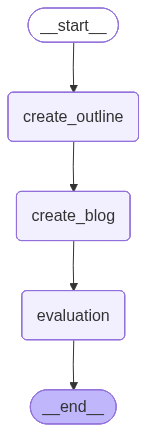

In [11]:
workflow = graph.compile()
workflow

In [12]:
tit = input("Enter the title")

In [13]:
initial_state = {"title": tit}

final_state = workflow.invoke(initial_state)

final_state

{'title': 'rise of ai in india',
 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Importance of AI in India\'s economic growth and development\n* Thesis statement: India is witnessing a significant rise in AI adoption, driven by government initiatives, technological advancements, and increasing demand for AI-powered solutions.\n\n**II. Current State of AI in India**\n\n* Overview of India\'s AI landscape, including key players, startups, and research institutions\n* Discussion of India\'s strengths in AI, such as:\n\t+ Large pool of skilled IT professionals\n\t+ Growing startup ecosystem\n\t+ Increasing investment in AI research and development\n* Challenges facing India\'s AI ecosystem, including:\n\t+ Limited access to high-quality data\n\t+ Lack of standardization and regulation\n\t+ Brain drain and talent acquisition challenges\n\n*

In [26]:
print(final_state['outline'])

Here is a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Importance of AI in India's economic growth and development
* Thesis statement: India is witnessing a significant rise in AI adoption, driven by government initiatives, technological advancements, and increasing demand for AI-powered solutions.

**II. Current State of AI in India**

* Overview of India's AI landscape, including key players, startups, and research institutions
* Discussion of India's strengths in AI, such as:
	+ Large pool of skilled IT professionals
	+ Growing startup ecosystem
	+ Increasing investment in AI research and development
* Challenges facing India's AI ecosystem, including:
	+ Limited access to high-quality data
	+ Lack of standardization and regulation
	+ Brain drain and talent acquisition challenges

**III. Government Initiatives and Policies**

* Overview of government initia

In [28]:
print(final_state['content'])

**The Rise of AI in India: A New Era of Innovation and Growth**

Artificial Intelligence (AI) has been transforming the world at an unprecedented pace, and India is no exception. With its growing importance in driving economic growth and development, AI has become a key focus area for the Indian government, industries, and academia. In this blog, we will explore the rise of AI in India, its current state, government initiatives, key applications, opportunities, challenges, and future outlook.

**Introduction**

AI refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. The technology has been gaining traction globally, with countries like the United States, China, and Japan leading the way. India, with its large pool of skilled IT professionals, growing startup ecosystem, and increasing investment in AI research and development, is witnessing a significant rise in AI adoption

In [14]:
print(final_state['score'])

I'd rate your blog an 8 out of 10. Here's why:

**Strengths:**

1. **Comprehensive coverage**: Your blog provides a thorough overview of the current state of AI in India, covering government initiatives, applications, opportunities, and challenges.
2. **Well-structured**: The blog is well-organized, making it easy to follow and understand.
3. **Informative**: You've provided a wealth of information on AI in India, including statistics, examples, and explanations of key concepts.
4. **Call to action**: You've included a clear call to action, encouraging readers to work together to promote AI adoption and innovation in India.

**Weaknesses:**

1. **Length**: The blog is quite long, which may deter some readers. Consider breaking it up into smaller, more manageable sections or posts.
2. **Lack of visuals**: The blog could benefit from images, charts, or infographics to break up the text and illustrate key points.
3. **Some sections feel repetitive**: A few sections, such as the "Opportuni